In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")


In [2]:
df = pd.read_csv("Protein_Dataset.csv")

In [3]:
print("Exploratory Data Analysis Questions")

questions = [
    "1. How many protein records are available?",
    "2. Which organism has the highest number of proteins?",
    "3. What is the average protein sequence length?",
    "4. Which protein has the highest molecular weight?",
    "5. Are there duplicate records?",
    "6. Are there missing values?",
    "7. Are there outliers in sequence length?",
    "8. Is molecular weight correlated with sequence length?"
]

for q in questions:
    print(q)


Exploratory Data Analysis Questions
1. How many protein records are available?
2. Which organism has the highest number of proteins?
3. What is the average protein sequence length?
4. Which protein has the highest molecular weight?
5. Are there duplicate records?
6. Are there missing values?
7. Are there outliers in sequence length?
8. Is molecular weight correlated with sequence length?


In [4]:
df.head()

df.shape

df.columns

df.info()

df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Accession              25 non-null     object
 1   Description            25 non-null     object
 2   Organism               25 non-null     object
 3   Sequence Length        25 non-null     int64 
 4   Amino Acid Count       25 non-null     int64 
 5   Molecular Weight (Da)  25 non-null     int64 
 6   Collection Date        25 non-null     object
 7   Country                25 non-null     object
 8   Protein Sequence       25 non-null     object
dtypes: int64(3), object(6)
memory usage: 1.9+ KB


,Sequence Length,Amino Acid Count,Molecular Weight (Da)
count,25.000000,25.000000,25.000000
mean,140.360000,140.360000,15439.600000
std,12.605819,12.605819,1386.640064
min,122.000000,122.000000,13420.000000
25%,129.000000,129.000000,14190.000000
50%,140.000000,140.000000,15400.000000
75%,144.000000,144.000000,15840.000000
max,166.000000,166.000000,18260.000000


In [5]:
df.isnull().sum()

Accession                0
Description              0
Organism                 0
Sequence Length          0
Amino Acid Count         0
Molecular Weight (Da)    0
Collection Date          0
Country                  0
Protein Sequence         0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

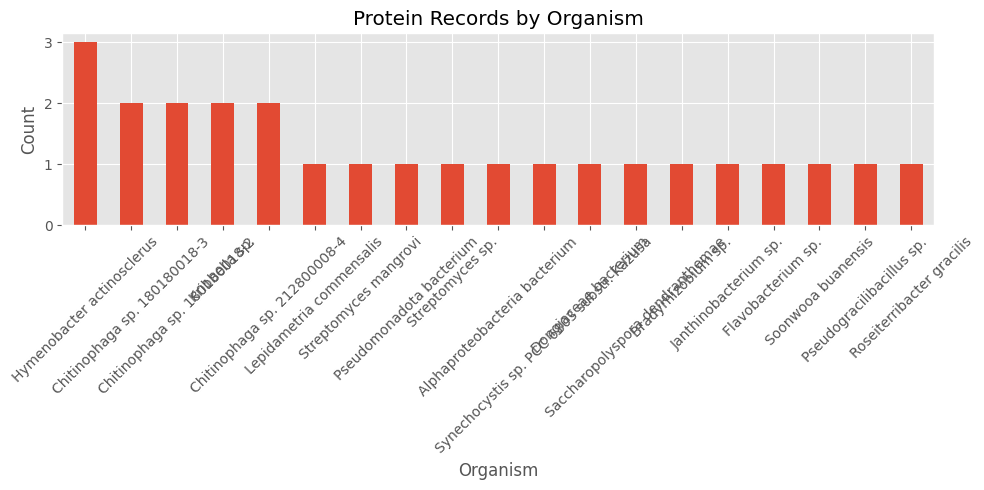

In [7]:
df["Organism"].value_counts()

#plot
plt.figure(figsize=(10,5))

df["Organism"].value_counts().plot(kind="bar")

plt.title("Protein Records by Organism")
plt.xlabel("Organism")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


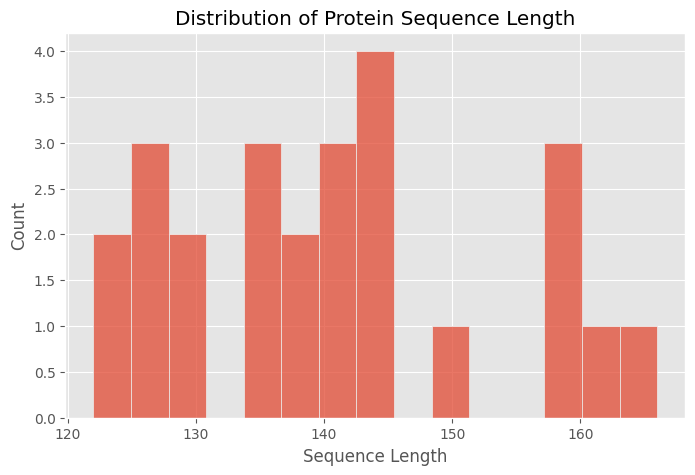

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df["Sequence Length"], bins=15)

plt.title("Distribution of Protein Sequence Length")

plt.show()


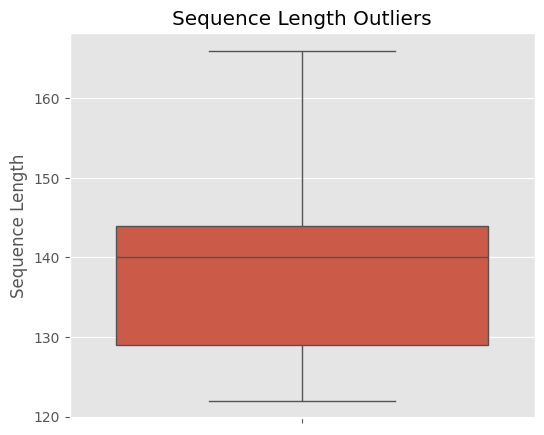

In [9]:
plt.figure(figsize=(6,5))

sns.boxplot(y=df["Sequence Length"])

plt.title("Sequence Length Outliers")

plt.show()


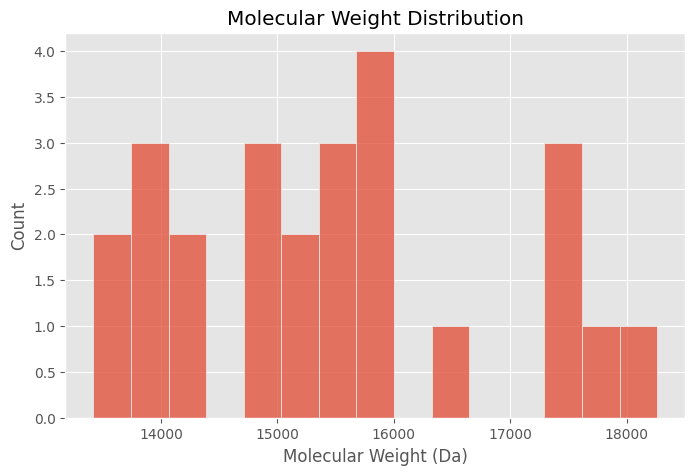

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df["Molecular Weight (Da)"], bins=15)

plt.title("Molecular Weight Distribution")

plt.show()


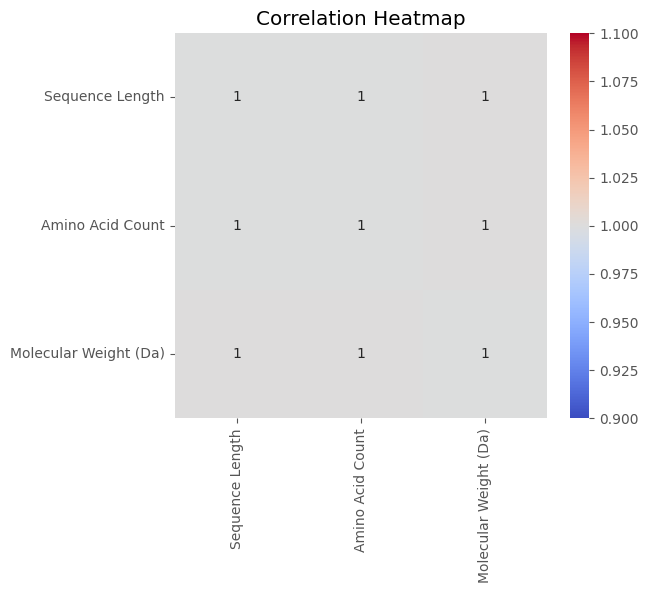

In [15]:
numeric = df.select_dtypes(include="number")
numeric.corr()
         #Heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()


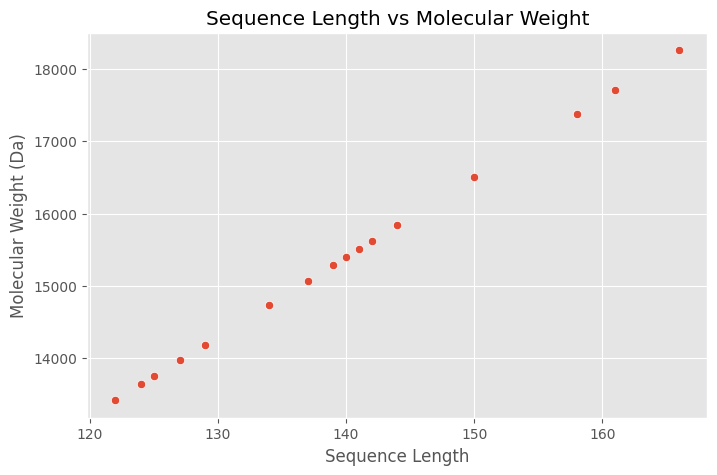

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Sequence Length",
    y="Molecular Weight (Da)"
)

plt.title("Sequence Length vs Molecular Weight")

plt.show()


In [17]:
df.sort_values(
    "Sequence Length",
    ascending=False
).head()


,Accession,Description,Organism,Sequence Length,Amino Acid Count,Molecular Weight (Da),Collection Date,Country,Protein Sequence
19,CAQ9209726.1,MAG: Hemoglobin [Hymenobacter actinosclerus],Hymenobacter actinosclerus,166,166,18260,2021,Not Available,MNRNLLATGLLACSLLLGACGGKEEAAAPTLYDRLGKTEGIASIVD...
13,CAR3643337.1,Hemoglobin [Alphaproteobacteria bacterium],Alphaproteobacteria bacterium,161,161,17710,2018,Not Available,MEIQSPRARMMAEIAERTGIDEAMIERLVRSFYAQVRNDALLGPVF...
5,WTM38401.1,Hemoglobin [Chitinophaga sp. 180180018-3],Chitinophaga sp. 180180018-3,158,158,17380,2017-10-30,Not Available,MTTGKNIPSLYEWAGGMPVFEKLTDEFYKKVVPDELLGPVFKHMSK...
7,WTM31928.1,Hemoglobin [Chitinophaga sp. 212800008-4],Chitinophaga sp. 212800008-4,158,158,17380,2021-09-06,Not Available,MTTGKNIPSLYEWAGGMPVFEKLTDEFYKKVVPDELLGPVFKHMSK...
3,WTM44874.1,Hemoglobin [Chitinophaga sp. 180180018-2],Chitinophaga sp. 180180018-2,158,158,17380,2017-10-30,Not Available,MTTGKNIPSLYEWAGGMPVFEKLTDEFYKKVVPDELLGPVFKHMSK...


In [18]:
print("Average Length :",df["Sequence Length"].mean())

print("Maximum Length :",df["Sequence Length"].max())

print("Minimum Length :",df["Sequence Length"].min())

print("Average Molecular Weight :",df["Molecular Weight (Da)"].mean())


Average Length : 140.36
Maximum Length : 166
Minimum Length : 122
Average Molecular Weight : 15439.6
